In [1]:
import sys
import os

os.chdir('../')
os.getcwd()

'c:\\Users\\luisa\\Documents\\LX1_GitHub_Repos\\ai_cheme_examples'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import hdbscan
import pacmap

from sklearn.preprocessing import MinMaxScaler
from scipy import stats

In [269]:
data = pd.read_excel('data/2.1-zw-Pyrolysis_Data 6-16_Reduced.xlsx')

data.head()


,Unnamed: 0,11FI05101PV,11FC05031PV1,11FC05032PV1,11FC05033PV1,11FC05034PV1,11FC05035PV1,11FC05036PV1,11FC05041PV1,11FC05042PV1,...,11TI05005PV,11TI05006PV,11TDC05011PV1,11TDC05012PV1,11TDC05013PV1,11TDC05014PV1,11TDC05015PV1,11PI05016PV,11TI05044PV,11TC05000PV1
0,2015-11-06 00:00:00.000000,52221.634263,8326.643312,8514.593137,8772.479316,8702.662279,8725.061214,8925.859148,4231.776051,4235.679965,...,611.155410,617.949135,835.685702,832.775546,837.579875,835.185782,837.532533,840.083022,1014.203860,838.564984
1,2015-11-06 00:20:00.000004,52265.900328,8365.639417,8556.450386,8785.182039,8691.885549,8703.588278,8947.979539,4234.084322,4235.981084,...,608.830187,615.503000,842.786275,857.657809,842.063391,831.472131,827.847198,829.859649,1003.212185,838.303879
2,2015-11-06 00:40:00.000008,52175.422216,8399.151486,8958.929290,8866.258307,8568.940794,8487.709325,8657.917877,4219.596998,4227.073918,...,612.223660,619.237611,832.882358,829.082685,836.141160,835.556342,839.504382,844.880867,1012.859396,837.527600
3,2015-11-06 01:00:00.000012,52301.058592,8371.304905,8755.843789,8816.456687,8648.966226,8614.722260,8805.725760,4235.860665,4242.020290,...,610.773671,617.620987,836.430164,833.785133,840.057993,838.177957,834.462237,833.534243,1011.943218,837.818136
4,2015-11-06 01:20:00.000016,52294.353809,8395.126075,8939.937799,8868.780738,8602.885921,8493.646648,8679.958967,4240.078093,4221.425555,...,610.275413,617.500575,839.643744,851.533809,842.807576,835.302639,827.123134,825.370441,1005.692422,837.338927


In [168]:
print(min(np.asarray([i.timestamp() for i in data.iloc[:, 0]])))
print(np.mean(np.asarray([i.timestamp() for i in data.iloc[:, 0]])))
print(max(np.asarray([i.timestamp() for i in data.iloc[:, 0]])))

1446768000.0
1450768619.4708126
1454768705.95


In [270]:
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
import matplotlib
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def plot_data(X, y, x_name, y_name, time = None, k = None):

    fig = plt.figure(figsize=(6, 5))
    axs0 = fig.add_subplot(1, 1, 1)

    #for col in data.iloc[:, 1:].columns:
    if time is not None:
        norm = TwoSlopeNorm(vmin=min(time), vcenter=np.mean(time), vmax=max(time))
        colors = [plt.cm.jet(norm(c)) for c in time]

    axs0.scatter(X, y, color = 'none', marker = 'o', edgecolors=colors, linewidth=1)

    if k is None:
        axs0.text(9000, 8000, s = 'All data', fontsize='x-large')
    else:
        axs0.text(9000, 8000, s = f'k = {k}', fontsize='x-large')

    axs0.set_xlabel(f'{x_name}', labelpad = 10, fontsize='x-large')
    axs0.set_ylabel(f'{y_name}', labelpad = 10, fontsize='x-large')

    axs0.tick_params(direction='out',
                        pad=10,
                        length=9,
                        width=1,
                        labelsize='x-large', 
                        #rotation=45
                        )

    axs0.tick_params(which='minor',
                        direction='out',
                        pad=10,
                        length=5,
                        width=1,
                        labelsize='x-large')

    for ax in ['top', 'bottom', 'left', 'right']:
        axs0.spines[ax].set_linewidth(1)

    cbaxes = inset_axes(axs0, width="30%", height="3%", loc='upper right')

    cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cm.jet), cax=cbaxes, shrink = 0.7, aspect = 30, orientation = 'horizontal')#, pad = 1)
    #plt.colorbar(cax=cbaxes, ticks=[0.,1], orientation='horizontal')

    
    cb.outline.set_linewidth(0.1)
    cb.ax.set_xlabel(r'$ \rm Time$', fontsize = 'x-large')
    cb.ax.tick_params(size=0)
    cb.set_ticks([])

    axs0.set_xlim(7250, 9500)
    axs0.set_ylim(7700, 9500)

    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                    ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=12
    plt.rcParams['axes.linewidth'] = 1 

    plt.show()

    return None

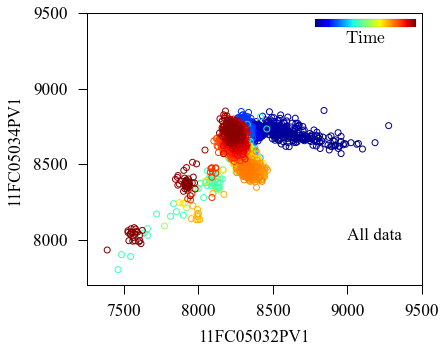

In [271]:
X = "11FC05032PV1"
y = "11FC05034PV1"

plot_data(data.iloc[:, data.columns.get_loc(X)], data.iloc[:, data.columns.get_loc(y)], X, y, time = np.asarray([i.timestamp() for i in data.iloc[:, 0]]))

In [272]:
from sklearn.cluster import KMeans
def get_clusters(data, basis_data = None, dr_model = None):
    scaler = MinMaxScaler(feature_range=(-1, 1))

    try:
        
        scaled_data = pd.DataFrame(scaler.fit_transform(data.iloc[:, 0:]))

    except:
        scaled_data = pd.DataFrame(scaler.fit_transform(data.iloc[:, 1:]))

    print(scaled_data.head())

    reduced_data = scaled_data

    # get clusters

    # cl_model = KMeans(n_clusters=5, random_state=0)
    cl_model = hdbscan.HDBSCAN(min_cluster_size=5)    

    labels = cl_model.fit_predict(reduced_data)

    data['labels'] = labels


    return data, dr_model, data.labels

In [318]:
data_reduced = pd.DataFrame()
data_reduced[X] = data.iloc[:, data.columns.get_loc(X)]
data_reduced[y] = data.iloc[:, data.columns.get_loc(y)]

data_clustered, dr_model, labels = get_clusters(data_reduced)

data_clustered.head()

          0         1
0  0.295393  0.765424
1  0.334001  0.748758
2  0.705238  0.558626
3  0.517917  0.682384
4  0.687721  0.611121


,11FC05032PV1,11FC05034PV1,labels
0,8514.593137,8702.662279,11
1,8556.450386,8691.885549,12
2,8958.929290,8568.940794,-1
3,8755.843789,8648.966226,-1
4,8939.937799,8602.885921,5


In [329]:
from imblearn.under_sampling import CondensedNearestNeighbour  

k = 5

cnn = CondensedNearestNeighbour(random_state=42, n_neighbors=k, sampling_strategy='auto')

data_sampled_cnn = cnn.fit_resample(data_clustered, data_clustered['labels'])[0]


data_sampled_cnn['post_index'] = cnn.sample_indices_

data_sampled_cnn = data_sampled_cnn.drop_duplicates()

data_sampled_cnn['time'] = data.iloc[data_sampled_cnn['post_index'], 0]



715
767


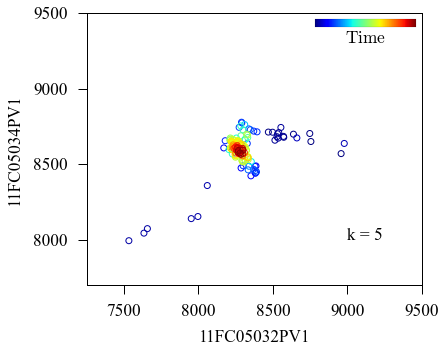

In [331]:
X = "11FC05032PV1"
y = "11FC05034PV1"

data_sampled_cnn = data_sampled_cnn.dropna()

plot_data(data_sampled_cnn.iloc[:, data_sampled_cnn.columns.get_loc(X)], data_sampled_cnn.iloc[:, data_sampled_cnn.columns.get_loc(y)], X, y, time = np.asarray([i.timestamp() for i in data_sampled_cnn['time']]), k = k)